## loading packages

In [1]:
import scanpy as sc
import warnings
import pandas as pd
import numpy as np
from scipy.sparse import block_diag

import matplotlib.pyplot as plt
import seaborn as sns

import os
import random
import torch
import torch.backends.cudnn as cudnn
from sklearn.decomposition import (
    PCA,
)
from sklearn.metrics import adjusted_rand_score 

from pathlib import Path
import scipy.sparse as sp
warnings.filterwarnings("ignore")

In [3]:
def fix_seed(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    cudnn.deterministic = True
    cudnn.benchmark = False

    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

In [4]:
#os.environ["R_HOME"] = "/home/lxx/.conda/envs/r4Base/lib/R"
#os.environ["R_USER"] = "/home/lxx/.local/lib/python3.9/site-packages/rpy2"

### ======== use the spCLUE package =========
# import spCLUE
fix_seed(42)

## loading data

In [5]:
def preprocess(adata, hvgNumber=None):
    print("normalized data ---------------->")
    sc.pp.filter_genes(adata, min_counts=1)
    sc.pp.filter_cells(adata, min_counts=1)
    if not hvgNumber is None:
        print(f"========== selecting HVG ============")
        sc.pp.highly_variable_genes(adata, flavor="seurat_v3", layer="count",n_top_genes=hvgNumber, subset=False)
        adata = adata[:, adata.var["highly_variable"] == True]
        sc.pp.scale(adata)
        return adata
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    sc.pp.scale(adata)
    return adata

In [6]:
data_root = Path('../../Data/Mouse_Embryo')

dlpfcs = ['E9.5_E1S1', 'E10.5_E2S1', "E11.5_E1S1"]

In [ ]:
adata_s = []
batch_list = []
for i, name in enumerate(dlpfcs):
    print(f"|================== Current slice: {name} ===============|")
    adata = sc.read_h5ad(data_root/ f"{name}.MOSTA.h5ad")
    #adata = sc.read_visium(data_root/ name, count_file=f"{name}_filtered_feature_bc_matrix.h5")
    adata.var_names_make_unique()

    # df_label = pd.read_csv(data_root / name / 'manual_annotations.txt', sep='\t', header=None, index_col=0)
    # df_label.columns = ['annotations']
    # adata.obs['annotations'] = df_label['annotations']

    if isinstance(adata.X, sp.csr_matrix):
        adata.X = adata.X.toarray()
    adata = preprocess(adata)
    adata_s.append(adata)
    batch_list += [i] * adata.shape[0]

batch_list = np.array(batch_list)
adata = sc.concat(adata_s)

|================== Current slice: E9.5_E1S1 ===============|
normalized data ---------------->
|================== Current slice: E10.5_E2S1 ===============|
normalized data ---------------->
|================== Current slice: E11.5_E1S1 ===============|
normalized data ---------------->


In [6]:
import scanpy as sc
from sklearn.decomposition import PCA
from scipy.spatial.distance import cdist
import numpy as np
import scipy.sparse as sp

def symm_norm(adj, weightDiag=.3, eps=1e-8):
    '''
    args: adjacent matrix with diag = 0
    return: D^{-1/2} (A + I) D^{-1 / 2}
    '''
    n_spot = adj.shape[0]
    adj_self = (1 - weightDiag) * adj + np.eye(n_spot) * weightDiag  
    degrees = 1. / np.sqrt((np.sum(adj_self, axis=1) + eps))
    adj_self *= degrees
    adj_self *= degrees[:, None]
    return adj_self.astype(np.float32)

def correlation_graph(A, B):
    '''calculate correlation between A and B.
    Args:
        A (np.ndarray): sample matrix, shape: [samples, features].
        B (np.ndarray): sample matrix, shape: [samples, features].
    Returns: 
        corr (np.ndarray): correlation matrix of features, shape: [features, features].
    '''
    am = A - np.mean(A, axis=0, keepdims=True)
    bm = B - np.mean(B, axis=0, keepdims=True)
    return am.T @ bm / (np.sqrt(np.sum(am**2, axis=0, keepdims=True)).T * np.sqrt(np.sum(bm**2, axis=0, keepdims=True)))

def prepare_graph(adata, key="spatial", n_neighbors=12, n_comps=50, eps=1e-8, svd_solver="randomized", self_weight=0.3):
    n_spots = adata.shape[0]
    assert key in ["spatial", "expr"], "case should be [spatial] or [expr]"
    if key == "spatial":
        print("create adjacent matrix from spatial idx --------------->")
        expr = adata.obsm[key]
        weights = 1. / (cdist(expr, expr, "euclidean") + eps)
    else:
        print("create adjacent matrix from pca expr --------------->")
        expr = PCA(n_components=n_comps, random_state=0, svd_solver=svd_solver).fit_transform(adata.X)
        weights = correlation_graph(expr.T, expr.T)

    print("create knn graph ---->")
    threshold = np.sort(weights)[:, -n_neighbors - 1:-n_neighbors]
    weights[weights < threshold] = 0
    weights = (weights + weights.T) / 2
    weights = weights * (1 - np.eye(n_spots))  # drop the diag

    adjFilter = 0. if key == "spatial" else 0.1
    # convert to bipartite case
    adjBip = np.where(weights > adjFilter, 1, 0)
    print(f"{key} knn graph created ----<")

    return sp.coo_matrix(symm_norm(adjBip, weightDiag=self_weight))

In [7]:
adata.obsm["X_pca"] = PCA(n_components=200, random_state=0).fit_transform(adata.X)

# spatial graph
g_spatial_list = []
for adata_cur in adata_s:
    g_spatial = prepare_graph(adata_cur, "spatial")
    g_spatial_list.append(g_spatial)
g_spatial = block_diag(g_spatial_list)

# expression graph
g_expr_list = []
for adata_cur in adata_s:
    g_expr = prepare_graph(adata_cur, "expr")
    g_expr_list.append(g_expr)
g_expr = block_diag(g_expr_list)

graph_dict = {"spatial": g_spatial, "expr": g_expr}

create adjacent matrix from spatial idx --------------->
create knn graph ---->
spatial knn graph created ----<
create adjacent matrix from spatial idx --------------->
create knn graph ---->
spatial knn graph created ----<
create adjacent matrix from spatial idx --------------->
create knn graph ---->
spatial knn graph created ----<
create adjacent matrix from pca expr --------------->
create knn graph ---->
expr knn graph created ----<
create adjacent matrix from pca expr --------------->
create knn graph ---->
expr knn graph created ----<
create adjacent matrix from pca expr --------------->
create knn graph ---->
expr knn graph created ----<


In [8]:
from spCLUE import spCLUE

n_clusters = 20

spCLUE_model = spCLUE(
    adata.obsm["X_pca"],
    graph_dict,
    n_clusters,
    batch_list,
    batch_train=True
)
_, adata.obsm["spCLUE"] = spCLUE_model.trainBatch()
adata.obs["batch_name"] = batch_list
adata.obs["batch_name"] = adata.obs["batch_name"].astype("category")

Training Start =========================>


 20%|█▉        | 99/500 [00:07<00:29, 13.44it/s]

epoch 100: 0.65


## clustering

In [9]:
from utils import *

cluster_method = "mclust"

clustering(adata,
            n_clusters,
            key='spCLUE',
            cluster_methods=cluster_method)
batch_refine_label(adata, key="mclust", batch_key="batch_name")

R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%


array(['17', '17', '17', ..., '13', '13', '13'], dtype='<U2')

In [7]:
adata = sc.read_h5ad('adata_spCLUE_MOE.h5ad')

In [8]:
from sklearn.metrics import adjusted_rand_score as ari_score
from sklearn.metrics import normalized_mutual_info_score as nmi_score
from sklearn.metrics import adjusted_mutual_info_score as ami_score
from sklearn.metrics import homogeneity_score as hom_score
from sklearn.metrics import completeness_score as com_score

In [9]:
sub_adata = adata[~pd.isnull(adata.obs['annotation'])]
ARI = adjusted_rand_score(sub_adata.obs['annotation'], sub_adata.obs['mclust'])
print(f"total ARI:{ARI}")
for i in range(len(dlpfcs)):
    sub_adata_tmp = sub_adata[sub_adata.obs['batch_name'] == i]
    ARI = adjusted_rand_score(sub_adata_tmp.obs['annotation'], sub_adata_tmp.obs['mclust'])
    print(f"{i} ARI:{ARI}")

total ARI:0.2993516109052801
0 ARI:0.31939268061216436
1 ARI:0.4938892219356532
2 ARI:0.3858109832990895


In [10]:
sub_adata = adata[~pd.isnull(adata.obs['annotation'])]
ARI = adjusted_rand_score(sub_adata.obs['annotation'], sub_adata.obs['mclust_refined'])
print(f"total ARI:{ARI}")
for i in range(len(dlpfcs)):
    sub_adata_tmp = sub_adata[sub_adata.obs['batch_name'] == i]
    ARI = adjusted_rand_score(sub_adata_tmp.obs['annotation'], sub_adata_tmp.obs['mclust_refined'])
    print(f"{i} ARI:{ARI}")

total ARI:0.28498346119036944
0 ARI:0.3121901557456231
1 ARI:0.3630732552709819
2 ARI:0.3779272568675972


In [10]:
sub_adata = adata[~pd.isnull(adata.obs['annotation'])]
NMI = nmi_score(sub_adata.obs['annotation'], sub_adata.obs['mclust_refined'])
print(f"total NMI:{NMI}")
for i in range(len(dlpfcs)):
    sub_adata_tmp = sub_adata[sub_adata.obs['batch_name'] == i]
    NMI = nmi_score(sub_adata_tmp.obs['annotation'], sub_adata_tmp.obs['mclust_refined'])
    print(f"{name} NMI:{NMI}")

total NMI:0.5279518551443927
E11.5_E1S1 NMI:0.5275284182104583
E11.5_E1S1 NMI:0.5736486551339416
E11.5_E1S1 NMI:0.6060983944001894


In [11]:
sub_adata = adata[~pd.isnull(adata.obs['annotation'])]
HOM = hom_score(sub_adata.obs['annotation'], sub_adata.obs['mclust_refined'])
print(f"total NMI:{HOM}")
for i in range(len(dlpfcs)):
    sub_adata_tmp = sub_adata[sub_adata.obs['batch_name'] == i]
    HOM = hom_score(sub_adata_tmp.obs['annotation'], sub_adata_tmp.obs['mclust_refined'])
    print(f"{name} HOM:{HOM}")

total NMI:0.5281054737968559
E11.5_E1S1 HOM:0.5480421842433668
E11.5_E1S1 HOM:0.5740770337000486
E11.5_E1S1 HOM:0.6239888251205202


In [15]:
import scib

sc.pp.neighbors(adata, use_rep="spCLUE")
scib.me.graph_connectivity(adata, label_key="annotation")

/root/miniconda3/envs/njy1/lib/python3.9/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)
/root/miniconda3/envs/njy1/lib/python3.9/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)
/root/miniconda3/envs/njy1/lib/python3.9/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)
/root/miniconda3/envs/njy1/lib/python3.9/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future v

0.9160609882414558

In [16]:
scib.me.silhouette_batch(adata, batch_key="batch_name", label_key="annotation", embed="spCLUE")

mean silhouette per group:                       silhouette_score
group                                 
Blood vessel                  0.665978
Brain                         0.772574
Branchial arch                0.353349
Cavity                        0.892141
Connective tissue             0.705410
Dermomyotome                  0.724019
Dorsal root ganglion          0.707518
Head mesenchyme               0.324359
Heart                         0.830685
Jaw and tooth                 0.506529
Liver                         0.689177
Lung primordium               0.319238
Mesenchyme                    0.713350
Notochord                     0.441292
Sclerotome                    0.788576
Spinal cord                   0.727499
Urogenital ridge              0.794496


0.6444818676986463

In [17]:
# import seaborn as sns
# import harmonypy as hm
# import matplotlib.pyplot as plt

# iLISI = hm.compute_lisi(adata.obsm['spCLUE'], adata.obs[['batch_name']], label_colnames=['batch_name'])[:, 0]
# cLISI = hm.compute_lisi(adata.obsm['spCLUE'], adata.obs[['annotation']], label_colnames=['annotation'])[:, 0]

# df_iLISI = pd.DataFrame({
#     'method': 'spCLUE',
#     'value': iLISI,
#     'type': ['ILISI'] * len(iLISI)
# })

# df_cLISI = pd.DataFrame({
#     'method': 'spCLUE',
#     'value': cLISI,
#     'type': ['CLISI'] * len(cLISI)
# })

# fig, axes = plt.subplots(1, 2, figsize=(4, 5))
# sns.boxplot(data=df_iLISI, x='method', y='value', ax=axes[0])
# sns.boxplot(data=df_cLISI, x='method', y='value', ax=axes[1])
# axes[0].set_ylim(1, 3)
# axes[1].set_ylim(1, 7)
# axes[0].set_title('iLISI')
# axes[1].set_title('cLISI')

# plt.tight_layout()
# print(np.median(iLISI))
# print(np.median(cLISI))

## Visualization

In [18]:
adata.obs['mclust'] = adata.obs['mclust'].astype('int')
adata.obs['mclust'] = adata.obs['mclust'].astype('category')

/root/miniconda3/envs/njy1/lib/python3.9/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/root/miniconda3/envs/njy1/lib/python3.9/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/root/miniconda3/envs/njy1/lib/python3.9/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


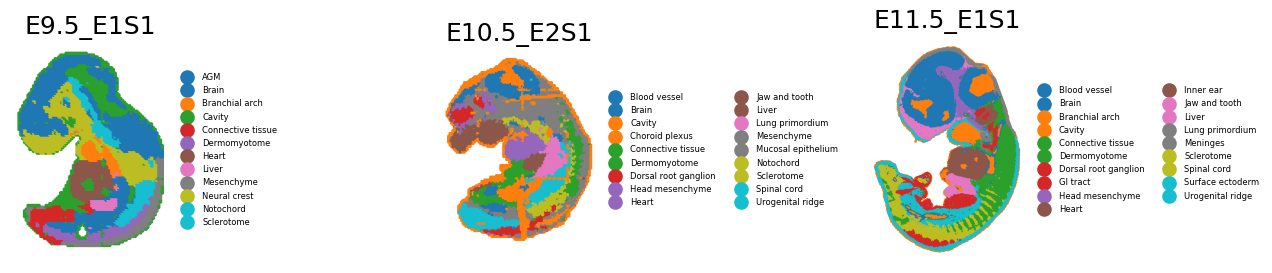

In [19]:
import matplotlib.pyplot as plt


plt.figure(figsize=(15, 10))
k = 1
spot_size = 2
for i in range(len(dlpfcs)):
    adata_tmp = adata[adata.obs['batch_name'] == i]
    ax = plt.subplot(2, 4, k)
    # sc.pl.embedding(adata_tmp, basis='spatial', color='annotation', s=45, ax=ax, show=False, legend_loc=False)
    sc.pl.spatial(adata_tmp, img_key=None, color=['annotation'], title=[''],
                  legend_loc='right margin', legend_fontsize=6, show=False, ax=ax, frameon=False,
                  spot_size=spot_size, palette='tab10')
    plt.title(f'{dlpfcs[i]}')
    k += 1
plt.tight_layout()

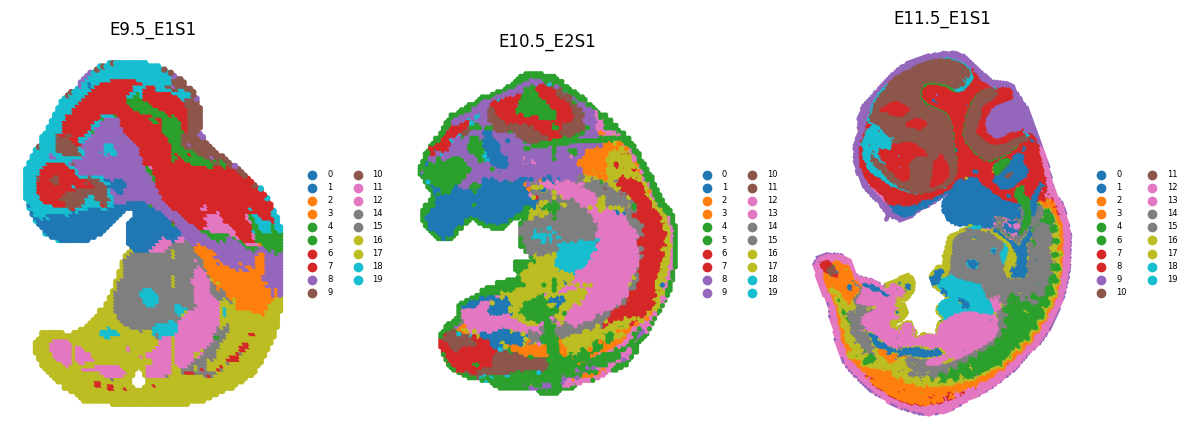

In [12]:
import matplotlib.pyplot as plt


plt.figure(figsize=(15, 10))
k = 1
spot_size = 2
for i in range(len(dlpfcs)):
    adata_tmp = adata[adata.obs['batch_name'] == i]
    ax = plt.subplot(2, 4, k)
    # sc.pl.embedding(adata_tmp, basis='spatial', color='annotation', s=45, ax=ax, show=False, legend_loc=False)
    sc.pl.spatial(adata_tmp, img_key=None, color=['mclust'], title=[''],
                  legend_loc='right margin', legend_fontsize=6, show=False, ax=ax, frameon=False,
                  spot_size=spot_size, palette='tab10')
    plt.title(f'{dlpfcs[i]}')
    k += 1
plt.tight_layout()

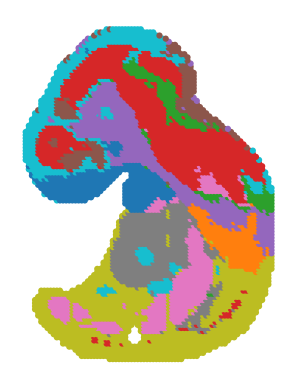

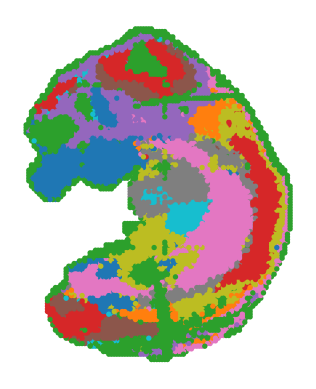

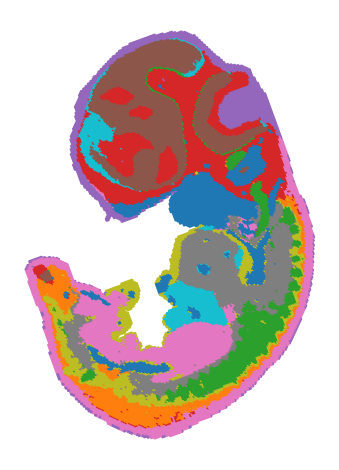

In [11]:
spot_size = 2
for i in range(len(dlpfcs)):
    adata_tmp = adata[adata.obs['batch_name'] == i]
    # sc.pl.embedding(adata_tmp, basis='spatial', color='annotation', s=45, ax=ax, show=False, legend_loc=False)
    sc.pl.spatial(adata_tmp, img_key=None, color=['mclust'], title=[''],
                  legend_loc=None, legend_fontsize=6, show=False, frameon=False,
                  spot_size=spot_size, palette='tab10')
    #plt.title(f'{dlpfcs[i]}')
    plt.savefig(f'spCLUE_{dlpfcs[i]}.jpg', bbox_inches='tight', dpi=300)
plt.tight_layout()

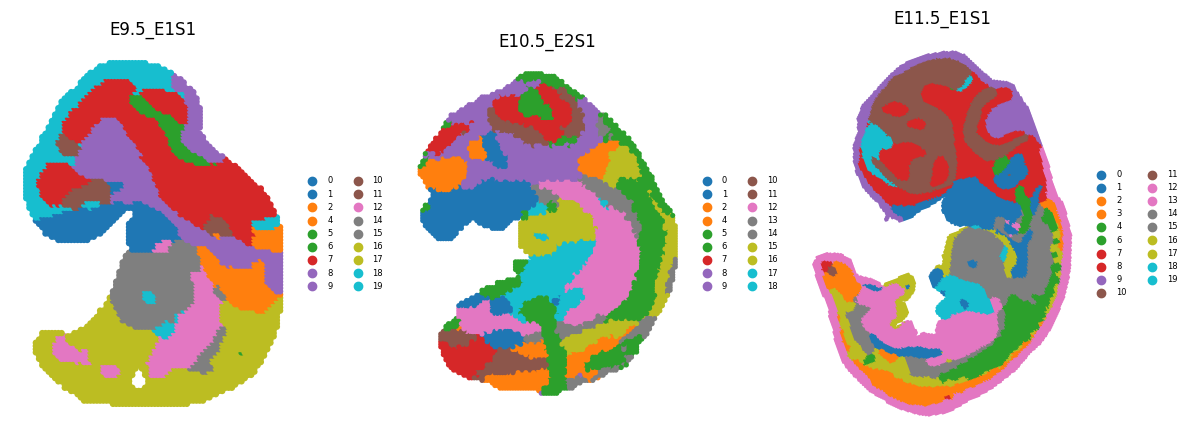

In [13]:
import matplotlib.pyplot as plt


plt.figure(figsize=(15, 10))
k = 1
spot_size = 2
for i in range(len(dlpfcs)):
    adata_tmp = adata[adata.obs['batch_name'] == i]
    ax = plt.subplot(2, 4, k)
    # sc.pl.embedding(adata_tmp, basis='spatial', color='annotation', s=45, ax=ax, show=False, legend_loc=False)
    sc.pl.spatial(adata_tmp, img_key=None, color=['mclust_refined'], title=[''],
                  legend_loc='right margin', legend_fontsize=6, show=False, ax=ax, frameon=False,
                  spot_size=spot_size, palette='tab10')
    plt.title(f'{dlpfcs[i]}')
    k += 1
plt.tight_layout()

In [22]:
# fig, axes = plt.subplots(3, 4, figsize=(12, 9))

# tmp = sns.color_palette("tab10")
# color_palette = {str(i):tmp[i] for i in range(n_clusters)}

# for i in range(3):
#     ax = axes[i // 4][i % 4]
#     cur = adata[adata.obs["batch_name"] == i]
#     cur.obsm["spatial"] = cur.obsm["spatial"] * np.array([1, -1])
#     cur_ari = adjusted_rand_score(cur.obs["Region"], cur.obs["mclust_refined"])
#     sc.pl.embedding(cur, basis="spatial", color="mclust_refined", palette=color_palette, ax=ax, show=False, legend_loc=None)
#     ax.set_xlabel("")
#     ax.set_ylabel("")
#     ax.set_title(f"{dlpfcs[i]} (ARI={cur_ari:.2f})")

In [ ]:
# adata.write('adata_spCLUE_MOE.h5ad')